# Notebook 13 - Statistical Evaluation of Experimental Results

## Objective

The purpose of this notebook is to perform a rigorous statistical analysis of the experimental results obtained from multiple independent training runs.

Unlike the previous notebooks, which focused on model development and evaluation, this notebook summarizes the experimental performance across repeated trials.

The following analyses are performed:

- Mean and Standard Deviation
- Minimum and Maximum Performance
- Boxplots of AUC and pAUC
- Performance Distribution
- Statistical Significance Tests
- Publication-ready Tables

### Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

from src.config import *


In [3]:
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["savefig.dpi"] = 300


In [4]:
results_df = pd.read_csv(results_path/"test_run_results.csv")
results_df.head()

,Run,Model,AUC,pAUC
0,1,Baseline AE,0.6912,0.7386
1,1,Handcrafted AE,0.9759,0.8994
2,1,Normalizing Flow,0.9859,0.9471
3,2,Baseline AE,0.7561,0.8320
4,2,Handcrafted AE,0.9744,0.9058


In [5]:

results_df.groupby('Model').size()

Model
Baseline AE         10
Handcrafted AE      10
Normalizing Flow    10
dtype: int64

In [6]:
results_df.columns

Index(['Run', 'Model', 'AUC', 'pAUC'], dtype='object')

In [7]:
results_df.isnull().sum()

Run      0
Model    0
AUC      0
pAUC     0
dtype: int64

In [8]:
summary = (
    results_df
    .groupby("Model")
    .agg(
        Mean_AUC=("AUC","mean"),
        Std_AUC=("AUC","std"),
        Min_AUC=("AUC","min"),
        Max_AUC=("AUC","max"),

        Mean_pAUC=("pAUC","mean"),
        Std_pAUC=("pAUC","std"),
        Min_pAUC=("pAUC","min"),
        Max_pAUC=("pAUC","max")
    )
)

summary

,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Mean_pAUC,Std_pAUC,Min_pAUC,Max_pAUC
Model,,,,,,,,
Baseline AE,0.72230,0.020508,0.6912,0.7561,0.79274,0.030692,0.7386,0.8320
Handcrafted AE,0.96931,0.007444,0.9541,0.9812,0.89922,0.010298,0.8805,0.9164
Normalizing Flow,0.98339,0.007566,0.9694,0.9939,0.94640,0.014455,0.9274,0.9710


In [9]:
summary = summary.round(4)

summary

,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Mean_pAUC,Std_pAUC,Min_pAUC,Max_pAUC
Model,,,,,,,,
Baseline AE,0.7223,0.0205,0.6912,0.7561,0.7927,0.0307,0.7386,0.8320
Handcrafted AE,0.9693,0.0074,0.9541,0.9812,0.8992,0.0103,0.8805,0.9164
Normalizing Flow,0.9834,0.0076,0.9694,0.9939,0.9464,0.0145,0.9274,0.9710


In [10]:
summary.to_csv(results_path/"summary_statistics.csv")

summary

,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Mean_pAUC,Std_pAUC,Min_pAUC,Max_pAUC
Model,,,,,,,,
Baseline AE,0.7223,0.0205,0.6912,0.7561,0.7927,0.0307,0.7386,0.8320
Handcrafted AE,0.9693,0.0074,0.9541,0.9812,0.8992,0.0103,0.8805,0.9164
Normalizing Flow,0.9834,0.0076,0.9694,0.9939,0.9464,0.0145,0.9274,0.9710


## Visualizations

### ROC-AUC Boxplot

The boxplot summarizes the distribution of ROC-AUC values obtained over ten independent experimental trials for each model. A narrow box indicates stable performance, whereas a wider box suggests higher variability across runs.

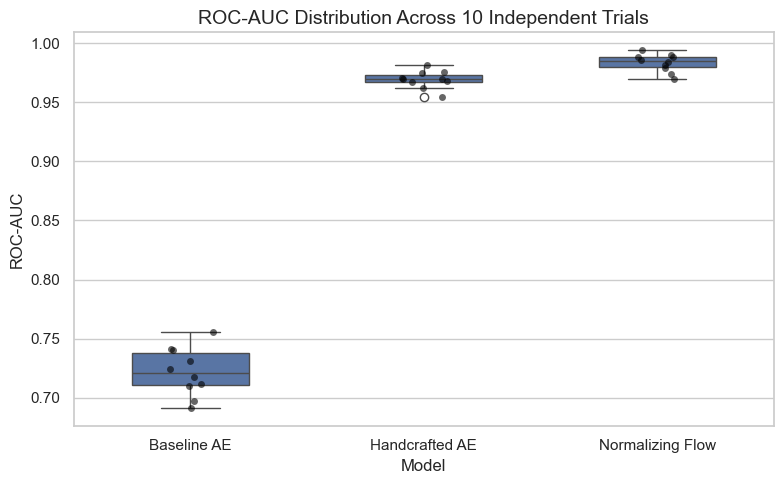

In [11]:
plt.figure(figsize = (8, 5))
sns.boxplot(data=results_df, x="Model", y="AUC", width=0.5)
sns.stripplot(data=results_df, x="Model", y="AUC", color="black", alpha=0.6, size=5)
plt.title("ROC-AUC Distribution Across 10 Independent Trials")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.tight_layout()
plt.savefig(results_path/"figures"/"statistical_evaluation"/"auc_boxplot.png",
            dpi = 300
)
plt.show()

### Partial ROC-AUC Distribution

Unlike ROC-AUC, pAUC evaluates model performance only in the low false-positive-rate region (FPR <= 0.1), making it more suitable for industrial anomaly detection.

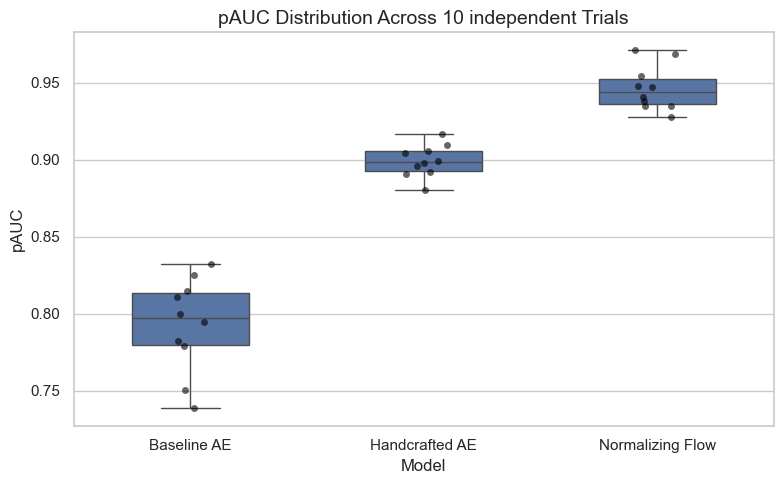

In [12]:
plt.figure(figsize = (8, 5))
sns.boxplot(data=results_df, x="Model", y="pAUC", width=0.5)
sns.stripplot(data=results_df, x="Model", y="pAUC", color="black", alpha=0.6, size=5)
plt.title("pAUC Distribution Across 10 independent Trials")
plt.xlabel("Model")
plt.ylabel("pAUC")
plt.tight_layout()
plt.savefig(results_path/"figures"/"statistical_evaluation"/"pauc_boxplot.png",
            dpi = 300
)
plt.show()

### Error Bar Plot - Mean Performance with Standard Deviation

The following plots present the average performance of each model together with one standard deviation computed from ten independent trials.


#### ROC-AUC Error Bar plot

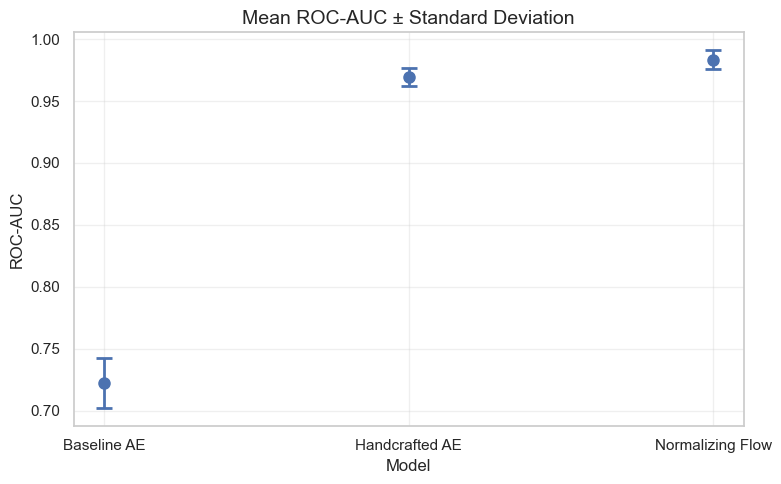

In [13]:
mean_auc = summary["Mean_AUC"]
std_auc = summary["Std_AUC"]
plt.figure(figsize=(8,5))
plt.errorbar(x=summary.index, y=mean_auc, yerr=std_auc,
            fmt='o', capsize=6, capthick=2, linewidth=2, markersize=8)
plt.title("Mean ROC-AUC ± Standard Deviation")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_path/"figures"/"statistical_evaluation"/"auc_errorbar.png",
            dpi = 300
)
plt.show()

#### pAUC Error Bar Plot

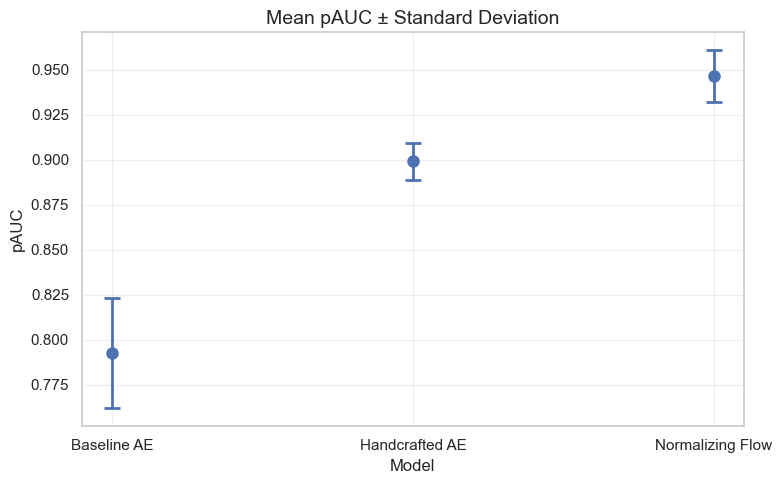

In [14]:
mean_pauc = summary["Mean_pAUC"]
std_pauc = summary["Std_pAUC"]
plt.figure(figsize = (8,5))
plt.errorbar(x=summary.index, y=mean_pauc, yerr=std_pauc, fmt='o',
            capsize=6, capthick=2, linewidth=2, markersize=8)
plt.title("Mean pAUC ± Standard Deviation")
plt.xlabel("Model")
plt.ylabel("pAUC")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(results_path/"figures"/"statistical_evaluation"/"pauc_errorbar.png",
            dpi = 300
)
plt.show()

### Performance Distribution

Histograms are used to visualize the frequency distribution of ROC-AUc values over repeated experiments.

#### ROC-AUC Histograms

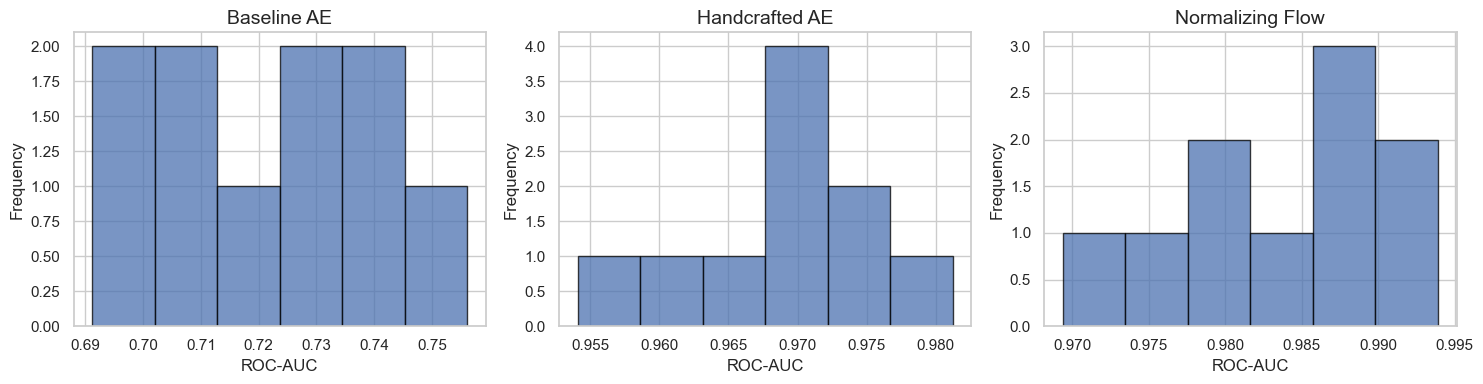

In [15]:
models = results_df["Model"].unique()
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, model in zip(axes, models):
    subset=results_df[results_df["Model"] == model]
    ax.hist(subset["AUC"], bins=6, edgecolor="black", alpha=0.75)
    ax.set_title(model)
    ax.set_xlabel("ROC-AUC")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig(results_path/"figures"/"statistical_evaluation"/"auc_histograms.png",
            dpi = 300
)
plt.show()

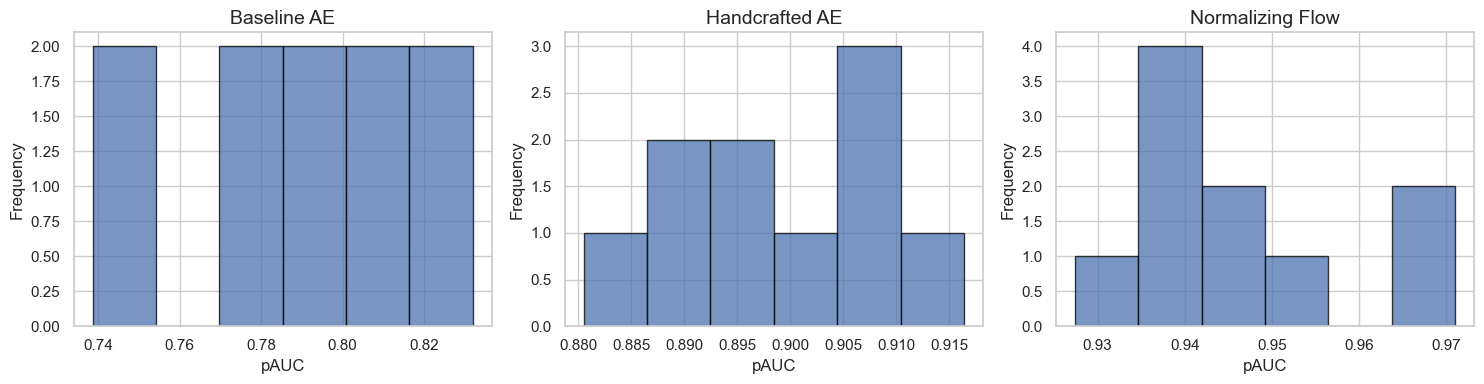

In [16]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

for ax, model in zip(axes, models):

    subset = results_df[results_df["Model"] == model]

    ax.hist(subset["pAUC"],bins=6,edgecolor="black",alpha=0.75)
    ax.set_title(model)
    ax.set_xlabel("pAUC")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(results_path/"figures"/"statistical_evaluation"/"pauc_histograms.png",
    dpi=300
)

plt.show()

## Statistical Significance Analysis

To determine whether the observed performance differences between models are statistically significant, paired statistical tests are performed.

Since each model was evaluated over the same ten experimental trials, paired tests are appropriate.

The analysis follows two steps:

1. Test whether the paired performance differences follow a normal distribution using the Shapiro–Wilk test.
2. Choose the statistical test:
   - Paired t-test if the differences are normally distributed.
   - Wilcoxon Signed-Rank test otherwise.

A significance level of α = 0.05 is used.

### Pivot Table

In [17]:
pivot_auc = results_df.pivot(index="Run", columns="Model", values="AUC")
pivot_pauc = results_df.pivot(index="Run", columns="Model", values="pAUC")

In [18]:
pivot_auc

Model,Baseline AE,Handcrafted AE,Normalizing Flow
Run,,,
1,0.6912,0.9759,0.9859
2,0.7561,0.9744,0.9939
3,0.7309,0.9681,0.9788
4,0.7417,0.9624,0.9739
5,0.7176,0.9812,0.9842
6,0.7246,0.9702,0.9816
7,0.7120,0.9669,0.9899
8,0.7408,0.9700,0.9694
9,0.7105,0.9541,0.9881


### Helper Function

In [19]:
def compare_models(model1, model2, metric_name, dataframe):
    
    x = dataframe[model1]
    y = dataframe[model2]

    diff = x - y

    shapiro_stat, shapiro_p = shapiro(diff)

    if shapiro_p > 0.05:

        test_name = "Paired t-test"

        stat, p_value = ttest_rel(x, y)

    else:

        test_name = "Wilcoxon Signed-Rank"

        stat, p_value = wilcoxon(x, y)

    return {
        "Metric": metric_name,
        "Model 1": model1,
        "Model 2": model2,
        "Normality p-value": shapiro_p,
        "Test": test_name,
        "Statistic": stat,
        "p-value": p_value,
        "Significant": p_value < 0.05
    }

### ROC-AUC Comparisons

In [20]:
auc_tests = []

auc_tests.append(
    compare_models(
        "Baseline AE",
        "Handcrafted AE",
        "ROC-AUC",
        pivot_auc
    )
)

auc_tests.append(
    compare_models(
        "Baseline AE",
        "Normalizing Flow",
        "ROC-AUC",
        pivot_auc
    )
)

auc_tests.append(
    compare_models(
        "Handcrafted AE",
        "Normalizing Flow",
        "ROC-AUC",
        pivot_auc
    )
)

auc_results = pd.DataFrame(auc_tests)

auc_results.round(5)

,Metric,Model 1,Model 2,Normality p-value,Test,Statistic,p-value,Significant
0,ROC-AUC,Baseline AE,Handcrafted AE,0.83235,Paired t-test,-35.56595,0.00000,True
1,ROC-AUC,Baseline AE,Normalizing Flow,0.49064,Paired t-test,-34.31783,0.00000,True
2,ROC-AUC,Handcrafted AE,Normalizing Flow,0.74716,Paired t-test,-4.44327,0.00162,True


### pAUC Comparisons

In [21]:
pauc_tests = []

pauc_tests.append(
    compare_models(
        "Baseline AE",
        "Handcrafted AE",
        "pAUC",
        pivot_pauc
    )
)

pauc_tests.append(
    compare_models(
        "Baseline AE",
        "Normalizing Flow",
        "pAUC",
        pivot_pauc
    )
)

pauc_tests.append(
    compare_models(
        "Handcrafted AE",
        "Normalizing Flow",
        "pAUC",
        pivot_pauc
    )
)

pauc_results = pd.DataFrame(pauc_tests)

pauc_results.round(5)

,Metric,Model 1,Model 2,Normality p-value,Test,Statistic,p-value,Significant
0,pAUC,Baseline AE,Handcrafted AE,0.06782,Paired t-test,-10.30000,0.00000,True
1,pAUC,Baseline AE,Normalizing Flow,0.72558,Paired t-test,-15.14791,0.00000,True
2,pAUC,Handcrafted AE,Normalizing Flow,0.93858,Paired t-test,-8.46602,0.00001,True


In [22]:
statistical_results = pd.concat(
    [auc_results, pauc_results],
    ignore_index=True
)

statistical_results.round(5)

,Metric,Model 1,Model 2,Normality p-value,Test,Statistic,p-value,Significant
0,ROC-AUC,Baseline AE,Handcrafted AE,0.83235,Paired t-test,-35.56595,0.00000,True
1,ROC-AUC,Baseline AE,Normalizing Flow,0.49064,Paired t-test,-34.31783,0.00000,True
2,ROC-AUC,Handcrafted AE,Normalizing Flow,0.74716,Paired t-test,-4.44327,0.00162,True
3,pAUC,Baseline AE,Handcrafted AE,0.06782,Paired t-test,-10.30000,0.00000,True
4,pAUC,Baseline AE,Normalizing Flow,0.72558,Paired t-test,-15.14791,0.00000,True
5,pAUC,Handcrafted AE,Normalizing Flow,0.93858,Paired t-test,-8.46602,0.00001,True


In [23]:
statistical_results.to_csv(
    results_path/ "statistical_significance.csv",
    index=False
)

statistical_results

,Metric,Model 1,Model 2,Normality p-value,Test,Statistic,p-value,Significant
0,ROC-AUC,Baseline AE,Handcrafted AE,0.832353,Paired t-test,-35.565953,5.432054e-11,True
1,ROC-AUC,Baseline AE,Normalizing Flow,0.490641,Paired t-test,-34.317826,7.475956e-11,True
2,ROC-AUC,Handcrafted AE,Normalizing Flow,0.747164,Paired t-test,-4.443274,1.615827e-03,True
3,pAUC,Baseline AE,Handcrafted AE,0.067819,Paired t-test,-10.299996,2.796318e-06,True
4,pAUC,Baseline AE,Normalizing Flow,0.725585,Paired t-test,-15.147905,1.035919e-07,True
5,pAUC,Handcrafted AE,Normalizing Flow,0.938584,Paired t-test,-8.466020,1.404176e-05,True


In [24]:
display_table = statistical_results.copy()
display_table["Normality p-value"] = display_table["Normality p-value"].round(4)
display_table["Statistic"] = display_table["Statistic"].round(4)
display_table["p-value"] = display_table["p-value"].round(5)
display_table

,Metric,Model 1,Model 2,Normality p-value,Test,Statistic,p-value,Significant
0,ROC-AUC,Baseline AE,Handcrafted AE,0.8324,Paired t-test,-35.5660,0.00000,True
1,ROC-AUC,Baseline AE,Normalizing Flow,0.4906,Paired t-test,-34.3178,0.00000,True
2,ROC-AUC,Handcrafted AE,Normalizing Flow,0.7472,Paired t-test,-4.4433,0.00162,True
3,pAUC,Baseline AE,Handcrafted AE,0.0678,Paired t-test,-10.3000,0.00000,True
4,pAUC,Baseline AE,Normalizing Flow,0.7256,Paired t-test,-15.1479,0.00000,True
5,pAUC,Handcrafted AE,Normalizing Flow,0.9386,Paired t-test,-8.4660,0.00001,True


## 13.10 Publication-ready Performance Table

The following table summarizes the average performance obtained over ten independent experimental trials.

The results are reported as:

**Mean ± Standard Deviation**

which is the standard reporting format used in most machine learning conferences.

In [25]:
publication_table = pd.DataFrame(index=summary.index)

publication_table["ROC-AUC"] = (
    summary["Mean_AUC"].map(lambda x: f"{x:.4f}")
    + " ± "
    + summary["Std_AUC"].map(lambda x: f"{x:.4f}")
)

publication_table["pAUC"] = (
    summary["Mean_pAUC"].map(lambda x: f"{x:.4f}")
    + " ± "
    + summary["Std_pAUC"].map(lambda x: f"{x:.4f}")
)

publication_table

,ROC-AUC,pAUC
Model,,
Baseline AE,0.7223 ± 0.0205,0.7927 ± 0.0307
Handcrafted AE,0.9693 ± 0.0074,0.8992 ± 0.0103
Normalizing Flow,0.9834 ± 0.0076,0.9464 ± 0.0145


In [26]:
publication_table.to_csv(
    results_path/ "paper_table_performance.csv"
)

publication_table

,ROC-AUC,pAUC
Model,,
Baseline AE,0.7223 ± 0.0205,0.7927 ± 0.0307
Handcrafted AE,0.9693 ± 0.0074,0.8992 ± 0.0103
Normalizing Flow,0.9834 ± 0.0076,0.9464 ± 0.0145


### Ranking Models

In [27]:
ranking = summary.sort_values(
    by="Mean_AUC",
    ascending=False
)

ranking[["Mean_AUC","Mean_pAUC"]]

,Mean_AUC,Mean_pAUC
Model,,
Normalizing Flow,0.9834,0.9464
Handcrafted AE,0.9693,0.8992
Baseline AE,0.7223,0.7927


### Best Model

In [28]:
best_model = ranking.index[0]

print(f"Best Performing Model : {best_model}")

print()

print(ranking.iloc[0])

Best Performing Model : Normalizing Flow

Mean_AUC     0.9834
Std_AUC      0.0076
Min_AUC      0.9694
Max_AUC      0.9939
Mean_pAUC    0.9464
Std_pAUC     0.0145
Min_pAUC     0.9274
Max_pAUC     0.9710
Name: Normalizing Flow, dtype: float64


### Improvement Over Baseline

In [29]:
baseline_auc = summary.loc["Baseline AE","Mean_AUC"]
baseline_pauc = summary.loc["Baseline AE","Mean_pAUC"]
comparison = summary.copy()
comparison["AUC Improvement"] = (comparison["Mean_AUC"] - baseline_auc)
comparison["pAUC Improvement"] = (comparison["Mean_pAUC"] - baseline_pauc)

comparison.round(4)

,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Mean_pAUC,Std_pAUC,Min_pAUC,Max_pAUC,AUC Improvement,pAUC Improvement
Model,,,,,,,,,,
Baseline AE,0.7223,0.0205,0.6912,0.7561,0.7927,0.0307,0.7386,0.8320,0.0000,0.0000
Handcrafted AE,0.9693,0.0074,0.9541,0.9812,0.8992,0.0103,0.8805,0.9164,0.2470,0.1065
Normalizing Flow,0.9834,0.0076,0.9694,0.9939,0.9464,0.0145,0.9274,0.9710,0.2611,0.1537


In [30]:
comparison.to_csv(
    results_path/"performance_improvement.csv"
)

comparison

,Mean_AUC,Std_AUC,Min_AUC,Max_AUC,Mean_pAUC,Std_pAUC,Min_pAUC,Max_pAUC,AUC Improvement,pAUC Improvement
Model,,,,,,,,,,
Baseline AE,0.7223,0.0205,0.6912,0.7561,0.7927,0.0307,0.7386,0.8320,0.0000,0.0000
Handcrafted AE,0.9693,0.0074,0.9541,0.9812,0.8992,0.0103,0.8805,0.9164,0.2470,0.1065
Normalizing Flow,0.9834,0.0076,0.9694,0.9939,0.9464,0.0145,0.9274,0.9710,0.2611,0.1537


In [ ]:
discussion = []

discussion.append("Experimental Summary")
discussion.append("-" * 60)
discussion.append("")
discussion.append(
    "Each model was trained and evaluated over ten independent experimental runs. "
    "The reported results correspond to the mean performance across these trials."
)
discussion.append("")

# Best model

best_model = summary["Mean_AUC"].idxmax()
best_auc = summary.loc[best_model, "Mean_AUC"]
best_pauc = summary.loc[best_model, "Mean_pAUC"]
discussion.append(
    f"The highest average ROC-AUC ({best_auc:.4f}) and "
    f"pAUC ({best_pauc:.4f}) were achieved by the "
    f"{best_model}."
)
discussion.append("")

# Compare models automatically

for _, row in statistical_results.iterrows():
    model1 = row["Model 1"]
    model2 = row["Model 2"]
    metric = row["Metric"]
    significant = row["Significant"]
    p = row["p-value"]

    if significant:
        discussion.append(
            f"For {metric}, the difference between "
            f"{model1} and {model2} was statistically "
            f"significant (p = {p:.5f})."
        )
    else:
        discussion.append(
            f"For {metric}, no statistically significant "
            f"difference was observed between "
            f"{model1} and {model2} "
            f"(p = {p:.5f})."
        )
discussion.append("")

# Stability

lowest_std_model = summary["Std_AUC"].idxmin()
discussion.append(
    f"The lowest performance variability was observed for "
    f"{lowest_std_model}, indicating the most stable "
    f"training behaviour across repeated trials."
)
discussion.append("")

# Feature representation

baseline_auc = summary.loc["Baseline AE", "Mean_AUC"]
handcrafted_auc = summary.loc["Handcrafted AE", "Mean_AUC"]
nf_auc = summary.loc["Normalizing Flow", "Mean_AUC"]
if handcrafted_auc > baseline_auc:
    discussion.append(
        "The handcrafted feature representation consistently "
        "outperformed the reproduced Log-Mel Spectrogram baseline."
    )
if nf_auc > handcrafted_auc:
    discussion.append(
        "The Normalizing Flow further improved the average "
        "performance over the handcrafted Autoencoder."
    )
discussion.append("")
discussion.append(
    "Overall, the experimental results demonstrates that the handcrafted feature"
    "representation is the primary contributor to the observed performance improvement,"
    "while the proposed Normalizing Flow provides a further statiscally significant enhancement"
    "over the handcrafted Autoencoder."
)
discussion = "\n".join(discussion)
print(discussion)


Experimental Summary
------------------------------------------------------------

Each model was trained and evaluated over ten independent experimental runs. The reported results correspond to the mean performance across these trials.

The highest average ROC-AUC (0.9834) and pAUC (0.9464) were achieved by the Normalizing Flow.

For ROC-AUC, the difference between Baseline AE and Handcrafted AE was statistically significant (p = 0.00000).
For ROC-AUC, the difference between Baseline AE and Normalizing Flow was statistically significant (p = 0.00000).
For ROC-AUC, the difference between Handcrafted AE and Normalizing Flow was statistically significant (p = 0.00162).
For pAUC, the difference between Baseline AE and Handcrafted AE was statistically significant (p = 0.00000).
For pAUC, the difference between Baseline AE and Normalizing Flow was statistically significant (p = 0.00000).
For pAUC, the difference between Handcrafted AE and Normalizing Flow was statistically significant (p = 